In [20]:
import os, sys, json
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

PROJECT_PATH = "/Users/manish/Documents/GitHub/Crop-disease-detection"
SRC_PATH  = os.path.join(PROJECT_PATH, "src")

for p in [PROJECT_PATH, SRC_PATH]:
    if p not in sys.path:
        sys.path.insert(0, p)

from config import CFG
from data_loader import prepare_data, LeafDataset, get_transforms
from evaluator import (load_model, predict, show_accuracy, show_metrics, show_confusion, plot_history)
print("Setup complete")


Setup complete


---
## Step 1 — Learning Curves

Shows how accuracy and loss changed during training for each setting.


MobileNetV2  |  baseline


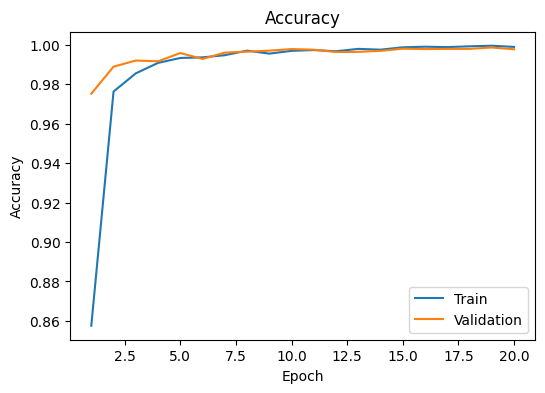

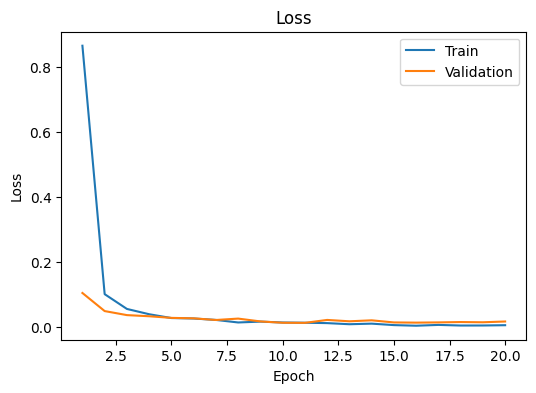


MobileNetV2  |  distorted


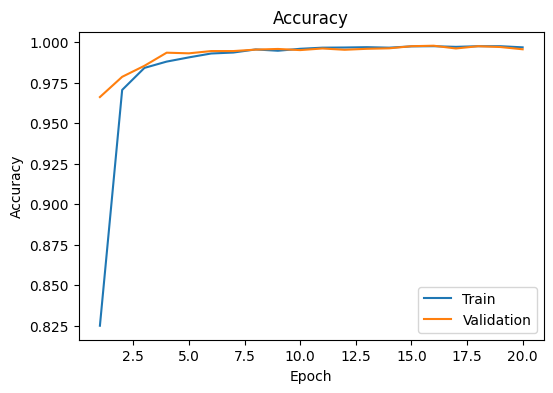

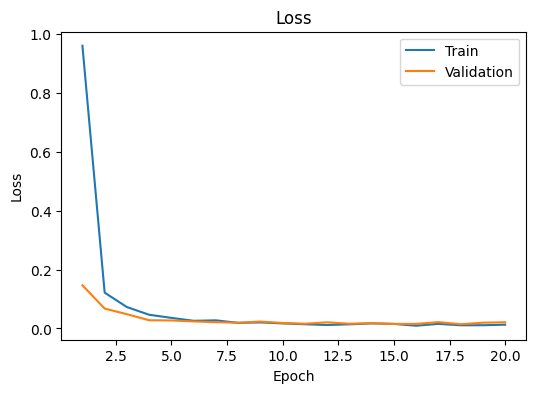


MobileNetV2  |  distorted1


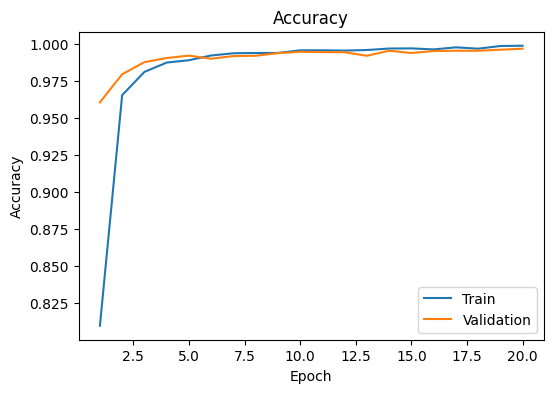

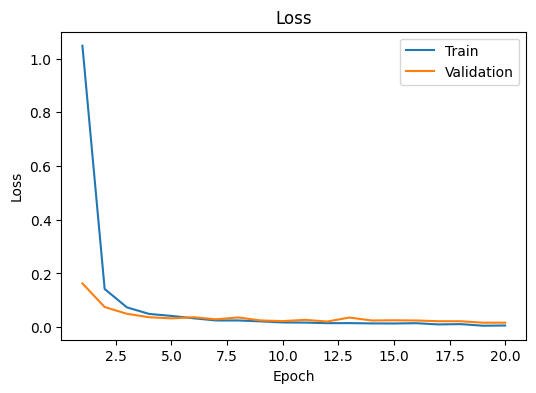

  Skipping augmented — not trained yet


In [2]:
for setting in ["baseline", "distorted", "distorted1", "augmented"]:
    hist_path = os.path.join(CFG["RESULTS_DIR"], f"MobileNetV2_{setting}_history.json")
    if os.path.exists(hist_path):
        print(f"\nMobileNetV2  |  {setting}")
        plot_history("MobileNetV2", setting, CFG)
    else:
        print(f"  Skipping {setting} — not trained yet")


---
## Step 3 — Load Test Datasets

In [3]:
def load_test_only(images_path, labels_path, cfg):
    images = np.load(images_path)
    labels = np.load(labels_path, allow_pickle=True)
    enc = LabelEncoder()
    labels_int = enc.fit_transform(labels)
    class_names = list(enc.classes_)
    _, X_test, _, y_test = train_test_split(
        images, labels_int,
        test_size=cfg["TEST_SIZE"], random_state=cfg["SEED"], stratify=labels_int,
    )
    _, val_tf = get_transforms(cfg)
    loader = DataLoader(
        LeafDataset(X_test, y_test, val_tf),
        batch_size=cfg["BATCH_SIZE"], shuffle=False, num_workers=cfg["NUM_WORKERS"],
    )
    print(f"Test images: {len(y_test)}")
    return loader, y_test, class_names

print("Loading clean test set")
loader_clean, y_test_clean, class_names = load_test_only(CFG["CLEAN_IMAGES"], CFG["CLEAN_LABELS"], CFG)

print("Loading droplet test set 1")
loader_drop, y_test_drop, _ = load_test_only(CFG["DROP_IMAGES"], CFG["DROP_LABELS"], CFG)

print("Loading droplet test set 2")
loader_drop2, y_test_drop2, _ = load_test_only(CFG["DROP_IMAGES_1"], CFG["DROP_LABELS_1"], CFG)


Loading clean test set
Test images: 10861
Loading droplet test set 1
Test images: 10861
Loading droplet test set 2
Test images: 10861


---
## Baseline — Clean Images

Run predictions once, then use in the 3 cells below.

In [4]:
print("Loading saved models")

model_baseline   = load_model("MobileNetV2", "baseline",   CFG)
model_distorted  = load_model("MobileNetV2", "distorted",  CFG)
model_distorted1 = load_model("MobileNetV2", "distorted1", CFG)

Loading saved models
  Total parameters    : 2,272,550
 Loaded: MobileNetV2_baseline_best.pth
  Total parameters    : 2,272,550
 Loaded: MobileNetV2_distorted_best.pth
  Total parameters    : 2,272,550
 Loaded: MobileNetV2_distorted1_best.pth


In [5]:
# Run predictions — call this once before the 3 cells below
y_pred_baseline, y_true_baseline = predict(model_baseline, loader_clean, CFG)

  Predictions ready — 10,861 test images


### Baseline — Cell 1: Test Accuracy

In [6]:
show_accuracy(y_pred_baseline, y_true_baseline, "MobileNetV2", "baseline")


  MobileNetV2  |  BASELINE

  Test Accuracy : 99.79%



### Baseline — Cell 2: Precision / Recall / F1

In [7]:
show_metrics(y_pred_baseline, y_true_baseline, class_names, "MobileNetV2", "baseline", CFG)


 Overall Metrics
  ──────────────────────────────────────────────────
  Metric                 Macro Avg   Weighted Avg
  ──────────────────────────────────────────────────
  Precision                 99.59%         99.79%
  Recall                    99.74%         99.79%
  F1-Score                  99.66%         99.79%

 Per Class Metrics
  ──────────────────────────────────────────────────
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9921    0.9960       126
                                 Apple___Black_rot     0.9920    1.0000    0.9960       124
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                                   Apple___healthy     1.0000    1.0000    1.0000       329
                               Blueberry___healthy     1.0000    1.0000    1.0000       300
          Cherry_(including_sour)___Powdery_mildew

### Baseline — Cell 3: Confusion Matrix + TP/FP/FN/TN

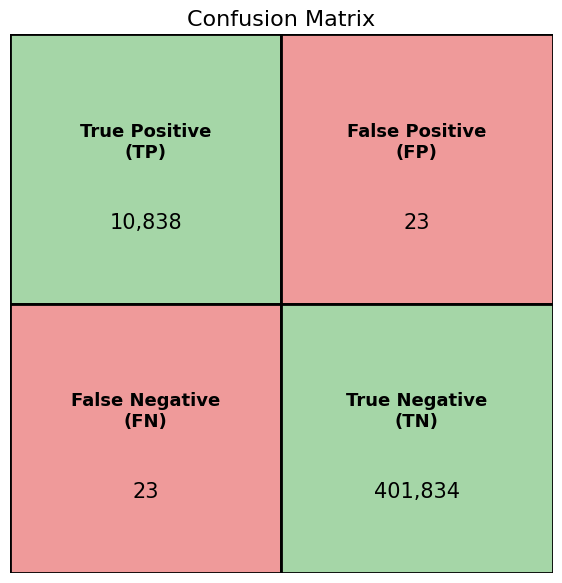

In [8]:
show_confusion(y_pred_baseline, y_true_baseline, class_names)

---
## Distorted — Droplet Dataset 1

In [9]:
y_pred_distorted, y_true_distorted = predict(model_distorted, loader_drop, CFG)

  Predictions ready — 10,861 test images


### Distorted — Cell 1: Test Accuracy

In [10]:
show_accuracy(y_pred_distorted, y_true_distorted, "MobileNetV2", "distorted")


  MobileNetV2  |  DISTORTED

  Test Accuracy : 99.67%



### Distorted — Cell 2: Precision / Recall / F1

In [11]:
show_metrics(y_pred_distorted, y_true_distorted, class_names, "MobileNetV2", "distorted", CFG)


 Overall Metrics
  ──────────────────────────────────────────────────
  Metric                 Macro Avg   Weighted Avg
  ──────────────────────────────────────────────────
  Precision                 99.57%         99.67%
  Recall                    99.57%         99.67%
  F1-Score                  99.57%         99.67%

 Per Class Metrics
  ──────────────────────────────────────────────────
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000       126
                                 Apple___Black_rot     1.0000    1.0000    1.0000       124
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                                   Apple___healthy     1.0000    0.9939    0.9970       329
                               Blueberry___healthy     0.9967    1.0000    0.9983       300
          Cherry_(including_sour)___Powdery_mildew

### Distorted — Cell 3: Confusion Matrix + TP/FP/FN/TN

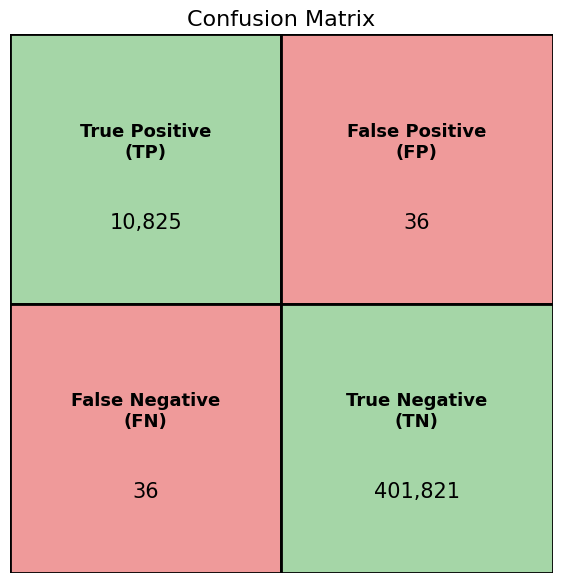

In [13]:
show_confusion(y_pred_distorted, y_true_distorted, class_names)

---
## Distorted 2 — Droplet Dataset 2

In [14]:
y_pred_distorted2, y_true_distorted2 = predict(model_distorted1, loader_drop2, CFG)


  Predictions ready — 10,861 test images


### Distorted 2 — Cell 1: Test Accuracy

In [15]:
show_accuracy(y_pred_distorted2, y_true_distorted2, "MobileNetV2", "distorted1")


  MobileNetV2  |  DISTORTED1

  Test Accuracy : 99.59%



### Distorted 2 — Cell 2: Precision / Recall / F1

In [17]:
show_metrics(y_pred_distorted2, y_true_distorted2, class_names, "MobileNetV2", "distorted2", CFG)


 Overall Metrics
  ──────────────────────────────────────────────────
  Metric                 Macro Avg   Weighted Avg
  ──────────────────────────────────────────────────
  Precision                 99.36%         99.59%
  Recall                    99.46%         99.59%
  F1-Score                  99.41%         99.59%

 Per Class Metrics
  ──────────────────────────────────────────────────
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000       126
                                 Apple___Black_rot     1.0000    1.0000    1.0000       124
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                                   Apple___healthy     1.0000    0.9939    0.9970       329
                               Blueberry___healthy     1.0000    0.9967    0.9983       300
          Cherry_(including_sour)___Powdery_mildew

### Distorted 2 — Cell 3: Confusion Matrix + TP/FP/FN/TN

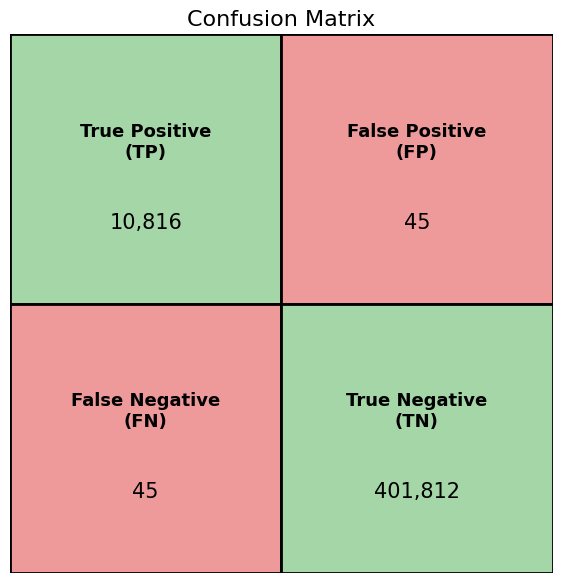

In [18]:
show_confusion(y_pred_distorted2, y_true_distorted2, class_names)

In [ ]:
device = CFG["DEVICE"]

target_layers = [model_distorted.features[-1]]               #Selected the last convolutional layer

drop_images = np.load(CFG["DROP_IMAGES"])
drop_labels = np.load(CFG["DROP_LABELS"], allow_pickle=True)

cam = GradCAM(model=model_distorted,
              target_layers=target_layers)                 #Created the gradcam object

encoder = LabelEncoder()
labels_int = encoder.fit_transform(drop_labels)
class_names = encoder.classes_                            #Converted the class into integer label

_, val_tf = get_transforms(CFG)                          #Load the same preprocessing used during model evaluation  

/Users/manish/Documents/GitHub/Crop-disease-detection/.venv-1/lib/python3.9/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


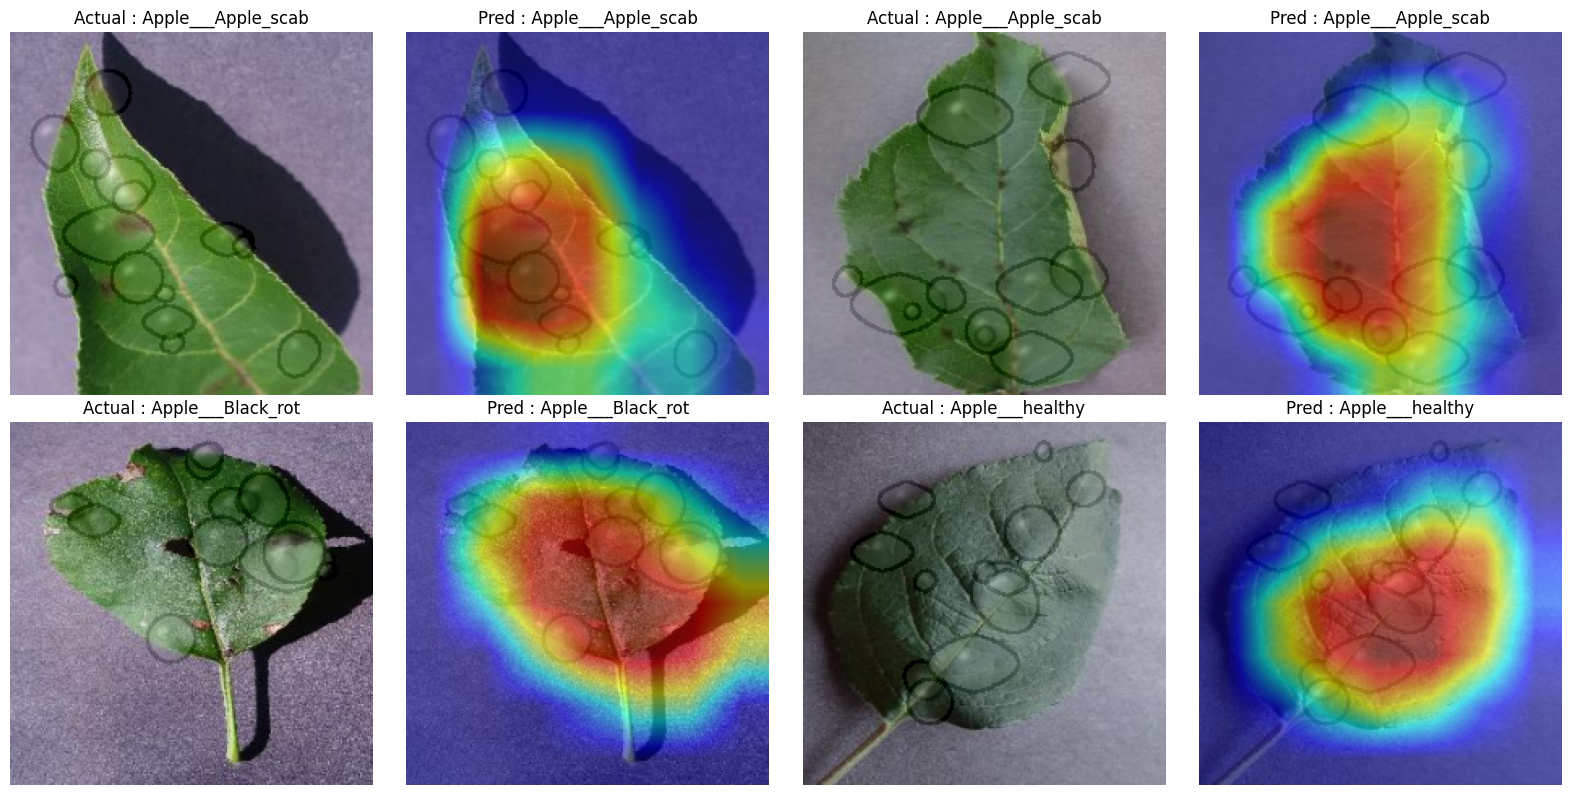

In [ ]:
indices = [0, 500, 1000, 2000]                         #Selected some sample images for visualization

fig, axes = plt.subplots(2,4, figsize=(16,8))

for i, idx in enumerate(indices):                        #Loop through each selected images

    row = i // 2
    col = (i % 2) * 2                        #row and column position

    # Get the original image and its true label
    original = drop_images[idx]
    true_cls = labels_int[idx]

    img_tensor = val_tf(original).unsqueeze(0).to(device)                        #apply preprocessing and move img to device
    pred_cls = model_distorted(img_tensor).argmax(dim=1).item()                  #predict the class using tarined model 

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(pred_cls)]                        #ganereate the gradcam for prediction classes
    )[0]

    overlay = show_cam_on_image(
        original.astype(np.float32) / 255.0,
        grayscale_cam,use_rgb=True)                                      #Overley the heatmap on the orignal images

    axes[row, col].imshow(original)
    axes[row, col].set_title(f"Actual : {class_names[true_cls]}")
    axes[row, col].axis("off")

    axes[row, col + 1].imshow(overlay)
    axes[row, col + 1].set_title(f"Pred : {class_names[pred_cls]}")
    axes[row, col + 1].axis("off")

plt.tight_layout()
plt.show()